## American-Job-Quality Study by Gallup ##
- Conducted between January 13 and February 25, 2025.
- Based on self-administered web and mail surveys from a random sample of 18,429 U.S. adults aged 18 to 75 who worked for pay in the prior seven days.
- Nationally representative of workers all over the country.
- A total of 3,040 cases were removed due to ineligibility or data quality issues.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df_labeled = pd.read_csv(
    '/Users/miskatulmoon/Downloads/JFF_formatted_public_release_labels.csv',
    encoding='cp1252'
)

#entries converted to numerical values
df_unlabeled = pd.read_csv(
    '/Users/miskatulmoon/Downloads/JFF_formatted_public_release_values.csv',
    encoding='cp1252'
)

/var/folders/5v/36m4ym_d3492xdw4y3xwfk980000gn/T/ipykernel_24958/2784219826.py:7: DtypeWarning: Columns (5: S1, 148: REGION, 149: DIVISION) have mixed types. Specify dtype option on import or set low_memory=False.
  df_unlabeled = pd.read_csv(


In [14]:
df_labeled.head()

,ENTITY_ID,SAMPLE,MODE,RESPONDENT_DATE,EndDate,S1,Q1,Q2,Q3,Q4,...,RACE6,RACE7,MARITAL_STATUS,EDUCATION,STATE,REGION,DIVISION,WORKER_TYPE,W2_STATUS,WEIGHT
0,4398199396,ABS Mail,Mail,1/28/2025,,,7,7,Very good,6,...,,White,Separated/divorced,High school graduate (high school diploma or e...,MA,Northeast,New England,Employee,W2 Worker,0.988427
1,4398199398,ABS Mail,Mail,1/28/2025,,,10-Completely satisfied,8,Excellent,10-Completely satisfied,...,,White,Married,"Four-year Bachelor's degree (e.g., BA, AB, BS)",MA,Northeast,New England,Employee,W2 Worker,0.184232
2,4398199412,ABS Mail,Mail,1/23/2025,,,8,8,Excellent,8,...,,White,Domestic partnership/Living with partner (not ...,"Advanced degree (Master's, professional, docto...",MA,Northeast,New England,Employee,W2 Worker,0.368465
3,4398199417,ABS Mail,Mail,1/30/2025,,,8,8,Very good,9,...,,White,Married,High school graduate (high school diploma or e...,MA,Northeast,New England,Self-employed IC,Non W2 Worker,3.341439
4,4398199431,ABS Web,Web,,1/16/2025 6:47:11,Yes,6,7,Very good,5,...,,,Domestic partnership/Living with partner (not ...,"Some college, no degree",MA,Northeast,New England,Employee,W2 Worker,1.515829


In [15]:
df_unlabeled.head()

,ENTITY_ID,SAMPLE,MODE,RESPONDENT_DATE,EndDate,S1,Q1,Q2,Q3,Q4,...,RACE6,RACE7,MARITAL_STATUS,EDUCATION,STATE,REGION,DIVISION,WORKER_TYPE,W2_STATUS,WEIGHT
0,4398199396,4,2,1/28/2025,,,7,7,2,6,...,,7,3,2,MA,1,1,1,1,0.988427
1,4398199398,4,2,1/28/2025,,,10,8,1,10,...,,7,2,5,MA,1,1,1,1,0.184232
2,4398199412,4,2,1/23/2025,,,8,8,1,8,...,,7,5,6,MA,1,1,1,1,0.368465
3,4398199417,4,2,1/30/2025,,,8,8,2,9,...,,7,2,2,MA,1,1,4,2,3.341439
4,4398199431,3,1,,1/16/2025 6:47:11,1,6,7,2,5,...,,,5,3,MA,1,1,1,1,1.515829


In [16]:
#unlabeled dataset has 0 missing values because 'No Response" is entered as -98
print("total missing values in unlabeled data:", df_unlabeled.isna().sum().sum())

#labeled dataset preserves NAN values for missing values, so we can see how many missing values are in the dataset
print("total missing values in labeled data:", df_labeled.isna().sum().sum())

total missing values in unlabeled data: 0
total missing values in labeled data: 18630


/var/folders/5v/36m4ym_d3492xdw4y3xwfk980000gn/T/ipykernel_24958/1722054207.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=q4_counts.index.astype(str), y=q4_counts.values, palette="viridis")


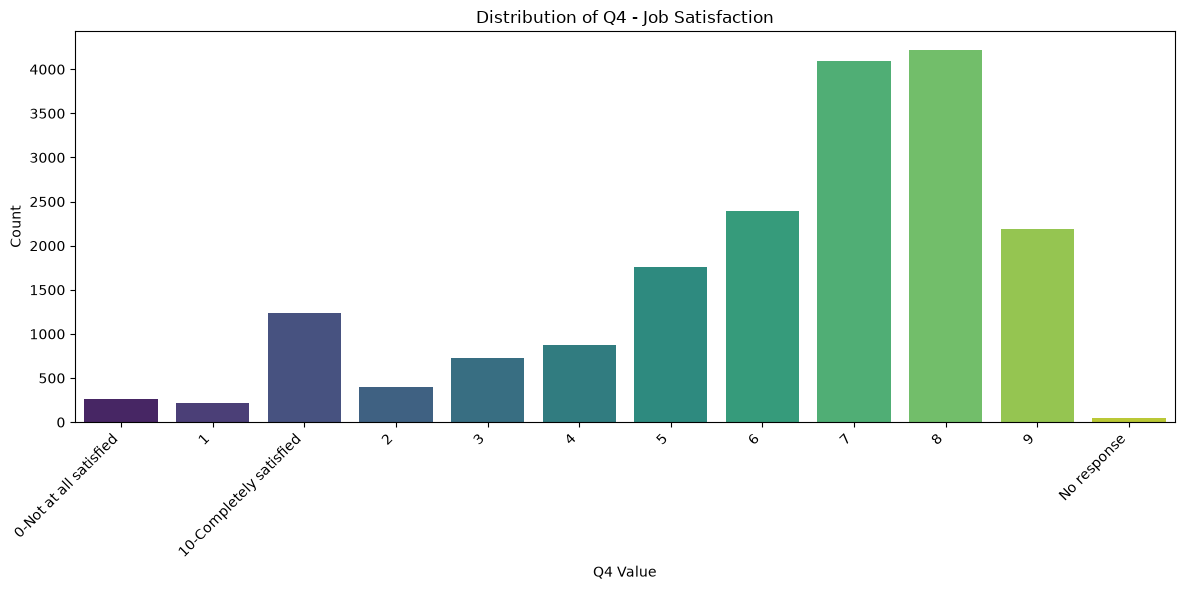

Q4
0-Not at all satisfied      264
1                           217
10-Completely satisfied    1238
2                           396
3                           728
4                           878
5                          1761
6                          2396
7                          4096
8                          4219
9                          2188
No response                  48
Name: count, dtype: int64


In [17]:
# Distribution of Q4 - our target variable: Job Satisfaction
import matplotlib.pyplot as plt
import seaborn as sns

q4_counts = df_labeled["Q4"].value_counts(dropna=False).sort_index()

plt.figure(figsize=(12,6))
sns.barplot(x=q4_counts.index.astype(str), y=q4_counts.values, palette="viridis")
plt.title("Distribution of Q4 - Job Satisfaction")
plt.xlabel("Q4 Value")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(q4_counts)


In [ ]:
print("Distinct values of Q6 - Main occupation: ")
print("\n")
for value in sorted(df_labeled["Q6"].dropna().unique()):
    print(value)


Distinct values of Q6 - Main occupation: 


Architecture and engineering
Arts, design, entertainment, sports, and media
Building and grounds cleaning and maintenance
Business and financial operations
Community and social service
Computer and mathematical
Construction and extraction
Educational instruction and library
Farming, fishing, and forestry
Food preparation and service
Healthcare practitioners
Healthcare support
Healthcare technicians
Installation, maintenance, and repair
Legal
Life, physical, and social science
Management
Military
No response
Office and administrative support
Personal care and service
Production
Protective service
Sales and related
Something else (please specify):
Transportation and material moving


In [35]:
print("Distinct values of Q6_TEXT - Write in responses: ")
print("\n")
for value in (df_labeled["Q6_TEXT"].dropna().unique()):
    print(value)


Distinct values of Q6_TEXT - Write in responses: 


 
HOME IMPROVEMENT
-98
LAW ENFORCEMENT
SEMI-RETIRED
public health
PSYCHOLOGIST/RESEARCH
CUSTOMER SERVICE
BANK TELLER
CASHIER RETAIL
Communication
US GOV
Pharma
TECHNICIAN VERIZON
MUNICIPAL GOVERNMENT
Fundraising writing
cdl delivery
MARKETING
Athletics
Mechanical Engineering
STEEL FABRICATOR
CASHIER
R&D
eLearning Developer
HEALTHCARE ADMINISTRATION
PRINTING
Direct care special needs
CHILD CARE
CERTIFIED PUBLIC ACCOUNTANT
retail customer service
MASTECTOMY FITTER
Journalism
SPEECH/LANGUAGE THERAPIST
Internal Auditor
HOSP CUSTODIAN
VETERINARY MEDICINE
POSTPARTUM DOULA
proveedora cuidado infantil
POLICE DISPATCHER
FUNERAL DIRECTOR
Minister, Religious worker
Teaching
HOSPITALITY
CHILDCARE
RESEARCH & DEVELOPMENT
MILITARY
Marketing
Education leadership/administration
CONSULTING STRATEGY
Paraprofessional personnel
Consulting - Business Intelligence
HUMAN RESOURCE EXEC
MINISTER
NANNY
AUTOMOTIVE REPAIR
JOUNALIST
Enforcement
Electrical generati

In [18]:
job_characteristics_features = ['S1', 'Q5', 'Q6', 'Q6_CODED', 'Q6_TEXT', 'Q7', 'Q7_CODED', 'Q7_TEXT', 'Q8', 'Q9', 'Q10', 'Q11', 'Q12', 'Q12_TEXT', 'Q13', 'Q14', 'Q15', 'Q15_TEXT', 'Q16', 'Q16_TEXT', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21', 'Q22', 'Q23', 'Q24', 'Q25A', 'Q25B', 'Q25C', 'Q25D', 'Q26_1', 'Q26_2', 'Q26_3', 'Q26_4', 'Q26_5', 'Q26_6', 'Q26_7', 'Q27', 'Q28', 'Q29', 'Q30', 'Q31A', 'Q31B', 'Q31C', 'Q32A', 'Q32B', 'Q32C', 'Q39', 'Q40', 'Q44', 'Q45', 'Q46', 'Q46_TEXT', 'Q48', 'Q49', 'Q49_TEXT', 'Q50', 'Q56_1', 'Q56_2', 'Q56_3', 'Q56_4', 'WORKER_TYPE', 'W2_STATUS']


In [19]:
sentiments_attitudes_features = ['Q1', 'Q2', 'Q3', 'Q41', 'Q42', 'Q43', 'Q47', 'Q59']


In [20]:
workplace_values_features = ['Q33A', 'Q33B', 'Q33C', 'Q33D', 'Q33E', 'Q33F', 'Q33G', 'Q33H', 'Q33I', 'Q33J', 'Q34', 'Q35A', 'Q35B', 'Q35C', 'Q35D', 'Q36', 'Q37A', 'Q37B', 'Q37C', 'Q37D', 'Q37E', 'Q37F', 'Q37G', 'Q37H', 'Q37I', 'Q38A', 'Q38B', 'Q38C']


In [21]:
demographics_festures = ['Q51', 'Q52', 'Q53', 'Q54A', 'Q54B', 'Q54C', 'Q55', 'Q55_TEXT', 'Q57', 'Q58', 'Q60', 'Q61_1', 'Q61_2', 'Q61_3', 'Q61_4', 'Q61_5', 'Q62', 'Q63', 'Q64_1', 'Q64_2', 'Q64_3', 'Q64_4', 'Q64_5', 'Q64_6', 'Q65', 'Q66_1', 'Q66_2', 'Q66_3', 'Q66_4', 'Q66_5', 'Q66_TEXT', 'Q67', 'Q68', 'MARITAL_STATUS', 'EDUCATION', 'STATE', 'REGION', 'DIVISION']
